# 02 — Walk-Forward OOS Test (PRIMARY)

**Run exactly once per spec configuration.** Re-running after seeing OOS
results would invalidate the pre-registration (see PRE_REGISTRATION.md §11).

Pre-registered protocol:
- Two parallel walk-forward windows (Expanding, Rolling 30y)
- Annual June re-estimation, 1976-07 ~ 2026-02 OOS
- 63-spec grid (slow=12, fast∈{1,2,3}, w_fast∈[-1, 1] step 0.1)
- Selection: max in-sample net Sharpe (excess of 1M Tbill)
- Test: Politis–Romano stationary block bootstrap, mean block 12, n_boot
  10000, seed 42, one-sided "greater"


In [1]:
import sys, os
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from trend import (fetch_ff49, fetch_tbill_1m,
                    grid_backtest, walkforward_oos,
                    lw_sharpe_diff_bootstrap,
                    summarize, sharpe_annualized,
                    plot_equity_with_drawdown, plot_bootstrap_dist,
                    plot_rolling_sharpe)
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})
RESULTS = "../results"
os.makedirs(RESULTS, exist_ok=True)


## 1. Build full-sample 63-spec grid

In [2]:
ff49 = fetch_ff49(cache_dir="../data")
rf   = fetch_tbill_1m(cache_dir="../data")
grid = grid_backtest(ff49, rf, tcost_bps=20.0)
print(f"grid shape: {grid.shape}")


grid shape: (1160, 63)


## 2. Walk-forward OOS — both protocols

In [3]:
oos_exp, hist_exp = walkforward_oos(grid, warmup_end="1976-06-30",
                                     train_window="expanding")
oos_r30, hist_r30 = walkforward_oos(grid, warmup_end="1976-06-30",
                                     train_window=30)
baseline = grid.loc[oos_exp.index, "fast=1,wf=+0.0"]
print(f"OOS sample: {oos_exp.index.min().date()} ~ {oos_exp.index.max().date()} ({len(oos_exp)} months)")
print(f"Decision dates per protocol: {len(hist_exp)}")


OOS sample: 1976-07-31 ~ 2026-02-28 (596 months)
Decision dates per protocol: 50


## 3. OOS summary statistics

In [4]:
summary_oos = pd.DataFrame({
    "Rolling-best (Expanding)": summarize(oos_exp),
    "Rolling-best (30y)":       summarize(oos_r30),
    "Static baseline (wf=0)":   summarize(baseline),
}).T
display(summary_oos.round(4))
summary_oos.to_csv(f"{RESULTS}/02_oos_summary.csv")


,CAGR,Vol,Sharpe,MDD,HitRate,Months
Rolling-best (Expanding),0.0385,0.1145,0.3863,-0.4601,0.5503,596.0
Rolling-best (30y),0.0364,0.1174,0.3631,-0.4144,0.5604,596.0
Static baseline (wf=0),0.0302,0.1118,0.3232,-0.3481,0.5822,596.0


## 4. Primary tests — Politis–Romano bootstrap

In [5]:
primary = {}
for name, oos in [("Expanding", oos_exp), ("Rolling 30y", oos_r30)]:
    out = lw_sharpe_diff_bootstrap(
        oos, baseline,
        mean_block_size=12, n_boot=10000, seed=42,
        alternative="greater",
    )
    primary[name] = out
    print(f"\n{name}:")
    print(f"  SR(rolling-best)   = {out['sr_a']:.4f}")
    print(f"  SR(static)         = {out['sr_b']:.4f}")
    print(f"  Δ Sharpe           = {out['delta']:+.4f}")
    print(f"  95% CI (Δ)         = [{out['ci_low_95']:+.4f}, {out['ci_high_95']:+.4f}]")
    print(f"  one-sided p-value  = {out['p_value']:.4f}")
    print(f"  decision           = {'REJECT H0' if out['p_value'] < 0.05 else 'fail to reject H0'}")



Expanding:
  SR(rolling-best)   = 0.3866
  SR(static)         = 0.3235
  Δ Sharpe           = +0.0631
  95% CI (Δ)         = [-0.1389, +0.2478]
  one-sided p-value  = 0.2540
  decision           = fail to reject H0



Rolling 30y:
  SR(rolling-best)   = 0.3634
  SR(static)         = 0.3235
  Δ Sharpe           = +0.0400
  95% CI (Δ)         = [-0.1389, +0.2119]
  one-sided p-value  = 0.3184
  decision           = fail to reject H0


## 5. Plots — equity / drawdown / bootstrap distributions

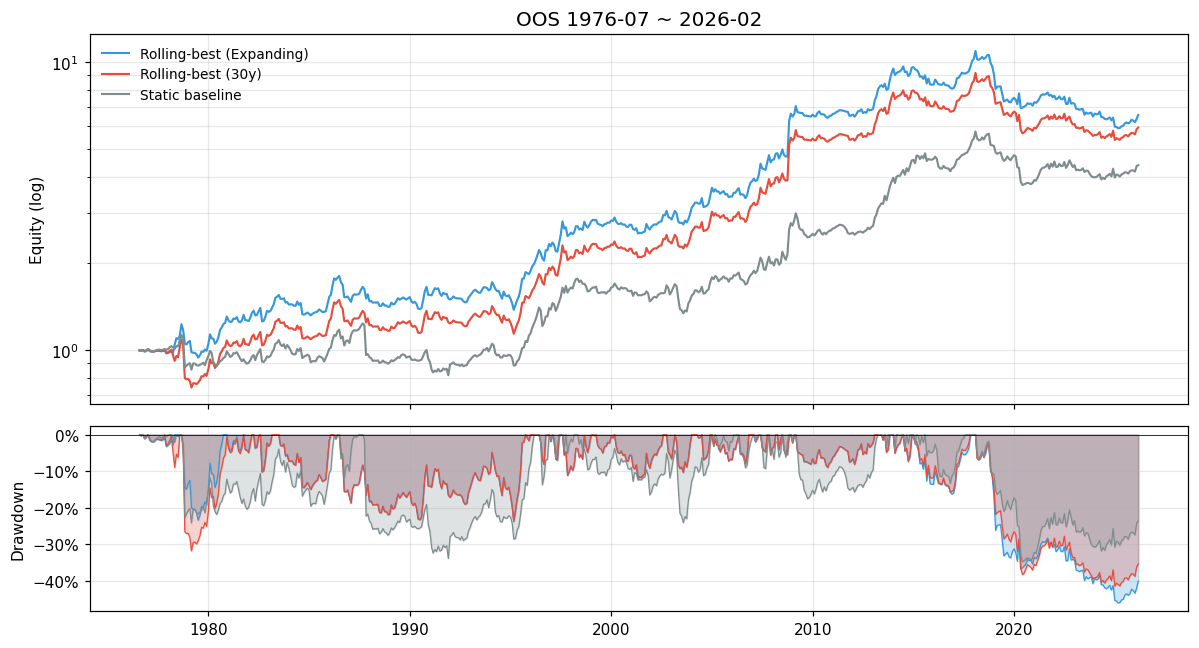

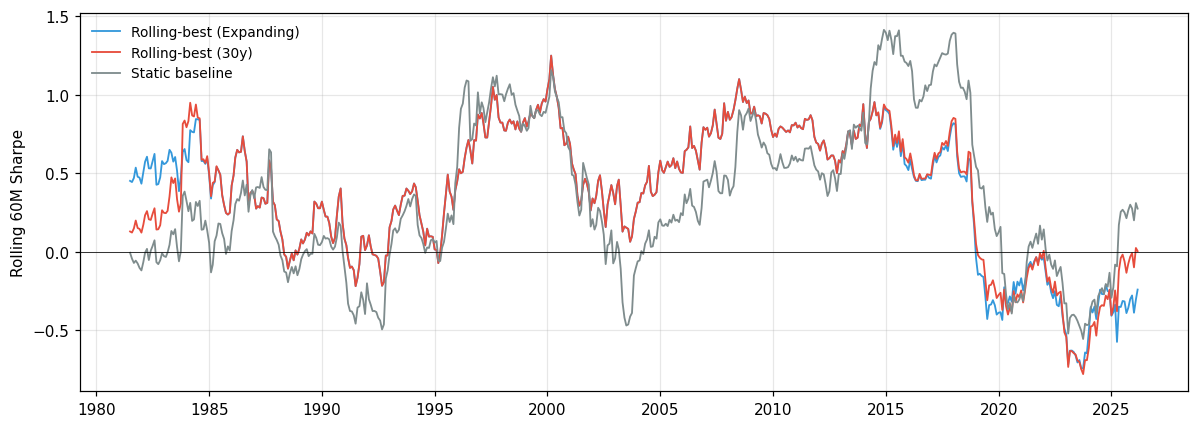

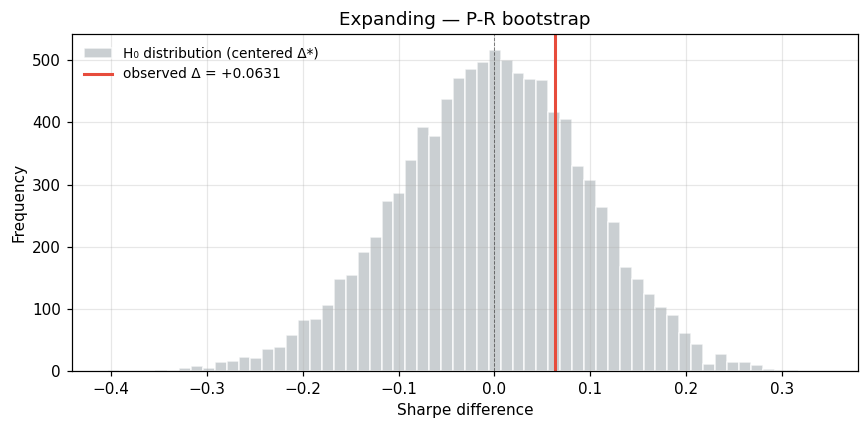

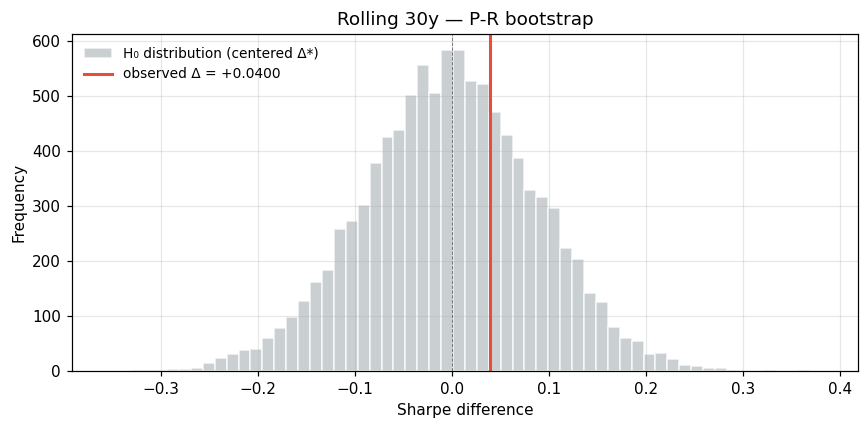

In [6]:
fig, _ = plot_equity_with_drawdown({
    "Rolling-best (Expanding)": oos_exp,
    "Rolling-best (30y)":       oos_r30,
    "Static baseline":          baseline,
}, title="OOS 1976-07 ~ 2026-02", log_scale=True)
fig.savefig(f"{RESULTS}/02_equity_drawdown.png", dpi=120, bbox_inches="tight")
plt.show()

fig, _ = plot_rolling_sharpe({
    "Rolling-best (Expanding)": oos_exp,
    "Rolling-best (30y)":       oos_r30,
    "Static baseline":          baseline,
}, window=60)
fig.savefig(f"{RESULTS}/02_rolling_sharpe.png", dpi=120, bbox_inches="tight")
plt.show()

for name in ["Expanding", "Rolling 30y"]:
    fig, _ = plot_bootstrap_dist(primary[name], title=f"{name} — P-R bootstrap")
    fig.savefig(f"{RESULTS}/02_bootstrap_{name.replace(' ','_')}.png", dpi=120, bbox_inches="tight")
    plt.show()


## 6. Save raw OOS series & spec history (for downstream notebooks)

In [7]:
pd.concat([
    oos_exp.rename("rolling_best_expanding"),
    oos_r30.rename("rolling_best_rolling30y"),
    baseline.rename("static_baseline"),
], axis=1).to_csv(f"{RESULTS}/02_oos_returns.csv")

hist_exp.to_csv(f"{RESULTS}/02_spec_history_expanding.csv")
hist_r30.to_csv(f"{RESULTS}/02_spec_history_rolling30y.csv")

print("Saved:")
for f in sorted(os.listdir(RESULTS)):
    if f.startswith("02_"): print(f"  {RESULTS}/{f}")


Saved:
  ../results/02_best_spec_ts.png
  ../results/02_bootstrap_Expanding.png
  ../results/02_bootstrap_Rolling_30y.png
  ../results/02_equity_drawdown.png
  ../results/02_oos_returns.csv
  ../results/02_oos_summary.csv
  ../results/02_rolling_sharpe.png
  ../results/02_spec_history_expanding.csv
  ../results/02_spec_history_rolling30y.csv
